In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded= files.upload()
for filename in uploaded.keys():
  print(f'Uploaded file: {filename}')

Saving student_placement_data.csv to student_placement_data.csv
Uploaded file: student_placement_data.csv


In [ ]:
df = pd.read_csv('student_placement_data.csv')
df

,CGPA,Skills,Internship,Projects,AptitudeScore,Placement
0,6.63,Good,No,5.0,77.0,0.0
1,7.07,Excellent,Yes,4.0,92.0,0.0
2,9.02,excellent,Yes,2.0,55.0,0.0
3,9.47,Good,No,0.0,86.0,0.0
4,9.30,Excellent,Yes,4.0,83.0,1.0
...,...,...,...,...,...,...
205,NaN,good,NaN,4.0,94.0,0.0
206,7.24,Poor,No,5.0,88.0,0.0
207,6.13,Excellent,No,2.0,91.0,0.0
208,7.91,Poor,Yes,2.0,54.0,0.0


In [ ]:
df.head()

,CGPA,Skills,Internship,Projects,AptitudeScore,Placement
0,6.63,Good,No,5.0,77.0,0.0
1,7.07,Excellent,Yes,4.0,92.0,0.0
2,9.02,excellent,Yes,2.0,55.0,0.0
3,9.47,Good,No,0.0,86.0,0.0
4,9.30,Excellent,Yes,4.0,83.0,1.0


In [ ]:
df.describe()

,CGPA,Projects,AptitudeScore,Placement
count,200.000000,200.000000,200.000000,200.000000
mean,7.755250,2.470000,70.330000,0.135000
std,1.009146,1.736137,14.680555,0.342581
min,6.010000,0.000000,45.000000,0.000000
25%,6.877500,1.000000,58.750000,0.000000
50%,7.780000,3.000000,70.000000,0.000000
75%,8.607500,4.000000,83.000000,0.000000
max,9.490000,5.000000,95.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CGPA           200 non-null    float64
 1   Skills         200 non-null    object 
 2   Internship     199 non-null    object 
 3   Projects       200 non-null    float64
 4   AptitudeScore  200 non-null    float64
 5   Placement      200 non-null    float64
dtypes: float64(4), object(2)
memory usage: 10.0+ KB


Handle missing values

In [ ]:
df.isnull().sum()

,0
CGPA,10
Skills,10
Internship,11
Projects,10
AptitudeScore,10
Placement,10


In [ ]:
df.isnull()

,CGPA,Skills,Internship,Projects,AptitudeScore,Placement
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
205,True,False,True,False,False,False
206,False,False,False,False,False,False
207,False,False,False,False,False,False
208,False,False,False,False,False,False


For numeric

In [ ]:
df['CGPA'] = df['CGPA'].fillna(df['CGPA'].mean())
df['Projects'] = df['Projects'].fillna(df['Projects'].mean())
df['AptitudeScore'] = df['AptitudeScore'].fillna(df['AptitudeScore'].mean())

For Categorial

In [ ]:
df['Skills'] = df['Skills'].fillna(df['Skills'].mode()[0])
df['Internship'] = df['Internship'].fillna(df['Internship'].mode()[0])

In [ ]:
df.isnull().sum()

,0
CGPA,0
Skills,0
Internship,0
Projects,0
AptitudeScore,0
Placement,10


Remove duplicates

In [ ]:
df = df.drop_duplicates()

EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

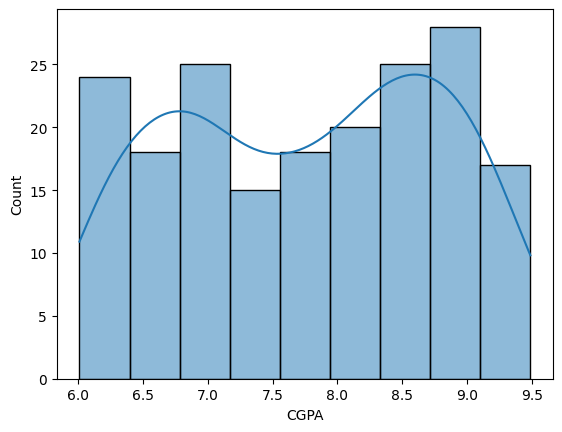

In [ ]:
sns.histplot(df['CGPA'], kde=True)
plt.show()

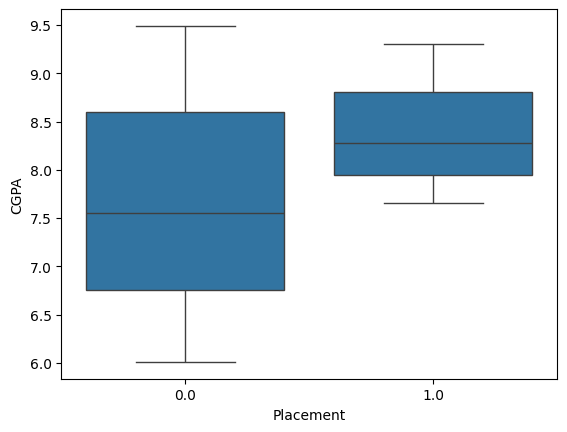

In [ ]:
sns.boxplot(x='Placement', y='CGPA', data=df)
plt.show()

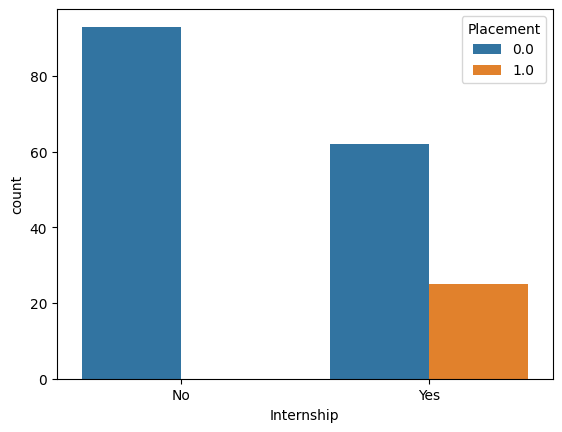

In [ ]:
sns.countplot(x='Internship', hue='Placement', data=df)
plt.show()

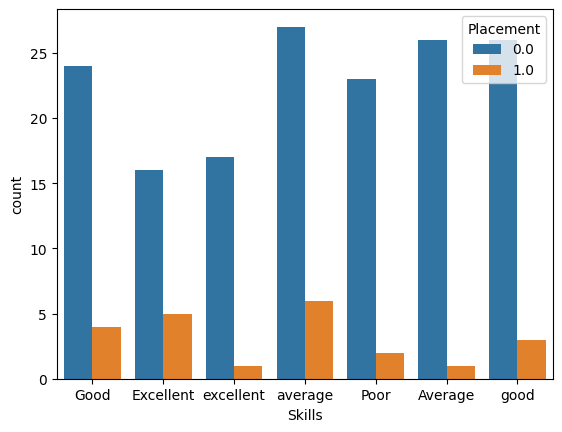

In [ ]:
sns.countplot(x='Skills', hue='Placement', data=df)
plt.show()

Correlation Heatmap

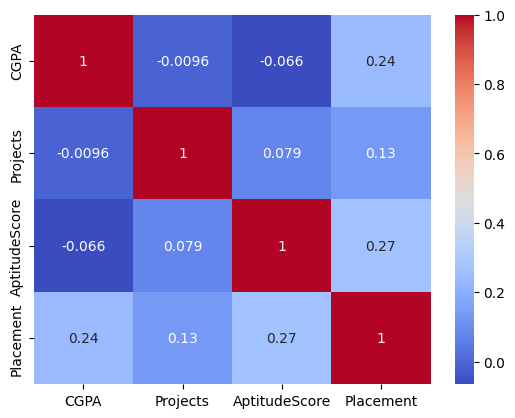

In [ ]:
import numpy as np
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()